# 03 — Feature Engineering
**Input**: `data/processed/telco_churn_cleaned.csv`  
**Output**: `data/processed/telco_churn_features.csv` + `models/scaler.pkl`

## 1. Imports & Load

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
FIGURES_DIR = '../reports/figures/'

df = pd.read_csv('../data/processed/telco_churn_cleaned.csv')
print(f'Loaded: {df.shape}')
df.head(3)

Loaded: (7021, 20)


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


## 2. Encode Binary (Yes/No) → 0/1

In [2]:
binary_yes_no = ['Partner', 'Dependents', 'Phone Service', 'Paperless Billing', 'Senior Citizen']
for col in binary_yes_no:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

print('✅ Binary encoded')
df[binary_yes_no + ['Gender']].head(3)

✅ Binary encoded


,Partner,Dependents,Phone Service,Paperless Billing,Senior Citizen,Gender
0,0,0,1,1,0,1
1,0,1,1,1,0,0
2,0,1,1,1,0,0


## 3. Encode 3-Way Service Columns

In [3]:
three_way_cols = [
    'Multiple Lines', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'
]
encode_map = {'Yes': 1, 'No': 0, 'No internet service': 0, 'No phone service': 0}
for col in three_way_cols:
    df[col] = df[col].map(encode_map)

print('✅ Three-way service columns encoded')
df[three_way_cols].head(3)

✅ Three-way service columns encoded


,Multiple Lines,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies
0,0,1,1,0,0,0,0
1,0,0,0,0,0,0,0
2,1,0,0,1,0,1,1


## 4. Ordinal Encode Contract

In [4]:
contract_map = {'Month-to-month': 0, 'One year': 1, 'Two year': 2}
df['Contract'] = df['Contract'].map(contract_map)
print('✅ Contract ordinal encoded:', contract_map)
df['Contract'].value_counts()

✅ Contract ordinal encoded: {'Month-to-month': 0, 'One year': 1, 'Two year': 2}


Contract
0    3853
2    1695
1    1473
Name: count, dtype: int64

## 5. One-Hot Encode Internet Service & Payment Method

In [5]:
before_cols = df.shape[1]
df = pd.get_dummies(df, columns=['Internet Service', 'Payment Method'], drop_first=False, dtype=int)
print(f'✅ One-hot encoded: added {df.shape[1] - before_cols} columns')
ohe_cols = [c for c in df.columns if 'Internet Service' in c or 'Payment Method' in c]
print('New columns:', ohe_cols)

✅ One-hot encoded: added 5 columns
New columns: ['Internet Service_DSL', 'Internet Service_Fiber optic', 'Internet Service_No', 'Payment Method_Bank transfer (automatic)', 'Payment Method_Credit card (automatic)', 'Payment Method_Electronic check', 'Payment Method_Mailed check']


## 6. Create New Features

In [6]:
# 1. Charges per month of tenure
df['Charges Per Month'] = (df['Total Charges'] / (df['Tenure Months'] + 1)).round(2)

# 2. Total services subscribed
service_cols = [
    'Phone Service', 'Multiple Lines', 'Online Security', 'Online Backup',
    'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies'
]
df['Num Services'] = df[service_cols].sum(axis=1)

# 3. Tenure group
df['Tenure Group'] = pd.cut(
    df['Tenure Months'], bins=[0, 12, 24, 48, 72],
    labels=[0, 1, 2, 3], include_lowest=True
).astype(int)

# 4. High value customer
threshold = df['Monthly Charges'].quantile(0.75)
df['High Value Customer'] = (df['Monthly Charges'] > threshold).astype(int)

# 5. Auto payment flag
auto_pay_cols = [c for c in df.columns if 'Bank transfer' in c or 'Credit card' in c]
df['Auto Payment'] = df[auto_pay_cols].max(axis=1)

print('✅ New features created: Charges Per Month, Num Services, Tenure Group, High Value Customer, Auto Payment')
df[['Charges Per Month','Num Services','Tenure Group','High Value Customer','Auto Payment']].head()

✅ New features created: Charges Per Month, Num Services, Tenure Group, High Value Customer, Auto Payment


,Charges Per Month,Num Services,Tenure Group,High Value Customer,Auto Payment
0,36.05,3,0,0,0
1,50.55,1,0,0,0
2,91.17,5,0,1,0
3,105.04,6,2,1,0
4,100.73,6,3,1,1


## 7. Scale Numerical Features

In [7]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Charges Per Month']
scaler = StandardScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

os.makedirs('../models', exist_ok=True)
joblib.dump(scaler, '../models/scaler.pkl')
print('✅ Scaled:', num_cols)
print('✅ Scaler saved: models/scaler.pkl')
df[num_cols].describe().round(3)

✅ Scaled: ['Tenure Months', 'Monthly Charges', 'Total Charges', 'Charges Per Month']
✅ Scaler saved: models/scaler.pkl


,Tenure Months,Monthly Charges,Total Charges,Charges Per Month
count,7021.000,7021.000,7021.000,7021.000
mean,0.000,-0.000,-0.000,-0.000
std,1.000,1.000,1.000,1.000
min,-1.323,-1.550,-1.001,-1.641
25%,-0.957,-0.968,-0.831,-1.077
50%,-0.141,0.185,-0.391,0.065
75%,0.918,0.833,0.668,0.844
max,1.611,1.793,2.823,1.962


## 8. Force All Columns to Numeric & Validate

In [8]:
# Critical — ensure no object columns remain before saving
df = df.apply(pd.to_numeric, errors='coerce').fillna(0)

print('Dtype counts:')
print(df.dtypes.value_counts())

object_cols = df.select_dtypes(include='object').columns.tolist()
if object_cols:
    print(f'⚠️  Still object: {object_cols}')
else:
    print('✅ No object columns — safe for XGBoost')

print(f'\nFinal shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'\nAll features:')
for i, c in enumerate([c for c in df.columns if c != 'Churn Value'], 1):
    print(f'  {i:2}. {c}')

Dtype counts:
int64      26
float64     4
Name: count, dtype: int64
✅ No object columns — safe for XGBoost

Final shape: (7021, 30)
Missing values: 0

All features:
   1. Gender
   2. Senior Citizen
   3. Partner
   4. Dependents
   5. Tenure Months
   6. Phone Service
   7. Multiple Lines
   8. Online Security
   9. Online Backup
  10. Device Protection
  11. Tech Support
  12. Streaming TV
  13. Streaming Movies
  14. Contract
  15. Paperless Billing
  16. Monthly Charges
  17. Total Charges
  18. Internet Service_DSL
  19. Internet Service_Fiber optic
  20. Internet Service_No
  21. Payment Method_Bank transfer (automatic)
  22. Payment Method_Credit card (automatic)
  23. Payment Method_Electronic check
  24. Payment Method_Mailed check
  25. Charges Per Month
  26. Num Services
  27. Tenure Group
  28. High Value Customer
  29. Auto Payment


## 9. Feature Correlation with Target

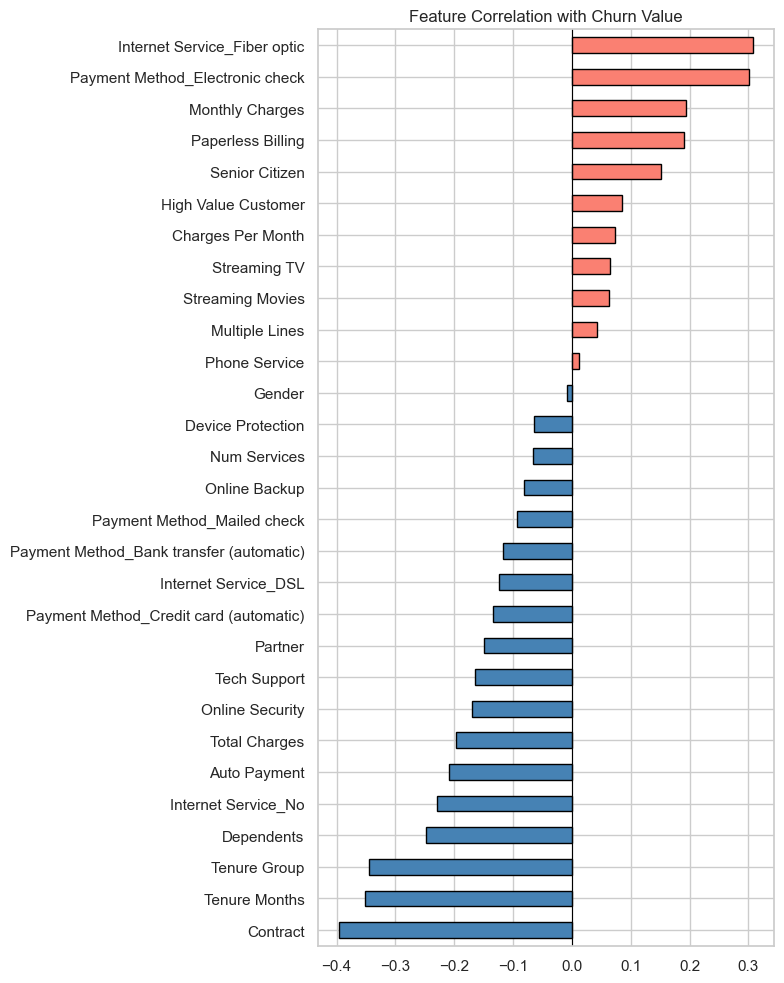

In [9]:
target_corr = df.corr()['Churn Value'].drop('Churn Value').sort_values()
fig, ax = plt.subplots(figsize=(8, 10))
colors = ['salmon' if v > 0 else 'steelblue' for v in target_corr]
target_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_title('Feature Correlation with Churn Value')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'feature_correlation_target.png')
plt.show()

## 10. Save Feature Matrix

In [11]:
df.to_csv('../data/processed/telco_churn_features.csv', index=False)
print('✅ Saved: data/processed/telco_churn_features.csv')
print(f'Shape: {df.shape}')


✅ Saved: data/processed/telco_churn_features.csv
Shape: (7021, 30)
